In [6]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import os

# 数据预处理
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 预训练模型需要 224x224 输入
    transforms.RandomHorizontalFlip(),  # 随机水平翻转（数据增强）
    transforms.RandomRotation(15),  # 随机旋转 ±15 度
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # 亮度/对比度变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet 统计的均值和标准差
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 如果本地没有数据，会自动下载
# 方式一：直接使用 PlantVillage 的彩色叶片数据集
data_dir = './data/PlantVillage'

# 如果数据还没下载，使用 torchvision 内置的简化版本（或用下面的手动下载代码）
try:
    full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
    print(f"成功加载本地数据，共 {len(full_dataset)} 张图片")
except FileNotFoundError:
    print("数据不存在，请查看下方的手动下载说明")
    raise

# 查看类别
class_names = full_dataset.classes
print(f"类别数量: {len(class_names)}")
print(f"类别名称: {class_names}")
print(f"每类图片数: {dict(zip(class_names, [len([1 for _, y in full_dataset if y == i]) for i in range(len(class_names))]))}")

成功加载本地数据，共 6625 张图片
类别数量: 4
类别名称: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']
每类图片数: {'Tomato___Bacterial_spot': 2127, 'Tomato___Early_blight': 1000, 'Tomato___Late_blight': 1907, 'Tomato___healthy': 1591}


In [7]:
# 80% 训练，20% 验证
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
# 验证集用 test_transform（不做数据增强）
val_dataset.dataset.transform = test_transform
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
print(f"训练集: {train_size} 张")
print(f"验证集: {val_size} 张")

训练集: 5300 张
验证集: 1325 张


In [12]:
# 加载在 ImageNet 上预训练的 ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
print(model)
# 查看模型结构的关键部分
print(f"\n卷积层数: {sum(1 for m in model.modules() if isinstance(m, nn.Conv2d))}")
print(f"全连接层输入维度: {model.fc.in_features}")
print(f"全连接层输出维度: {model.fc.out_features} (ImageNet 的 1000 类)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n当前设备: {device}")

# 冻结所有参数
for param in model.parameters():
    param.requires_grad = False

# 替换最后一层全连接层（4 类番茄病害）
num_classes = len(class_names)  # 4
model.fc = nn.Linear(model.fc.in_features, num_classes)

# 只有新替换的 fc 层需要训练
trainable_params = [p for p in model.parameters() if p.requires_grad]
print(f"可训练参数: {sum(p.numel() for p in trainable_params)}")
print(f"总参数: {sum(p.numel() for p in model.parameters())}")

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)


当前设备: cuda
可训练参数: 2052
总参数: 11178564


In [14]:
epochs = 5
train_losses, val_accs = [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # 验证
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(train_loader)
    val_acc = 100. * correct / total
    train_losses.append(avg_loss)
    val_accs.append(val_acc)
    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.2f}%")

Epoch [1/5] | Loss: 0.5437 | Val Acc: 88.68%
Epoch [2/5] | Loss: 0.2743 | Val Acc: 92.98%
Epoch [3/5] | Loss: 0.2166 | Val Acc: 95.40%
Epoch [4/5] | Loss: 0.1963 | Val Acc: 94.04%
Epoch [5/5] | Loss: 0.1643 | Val Acc: 95.85%


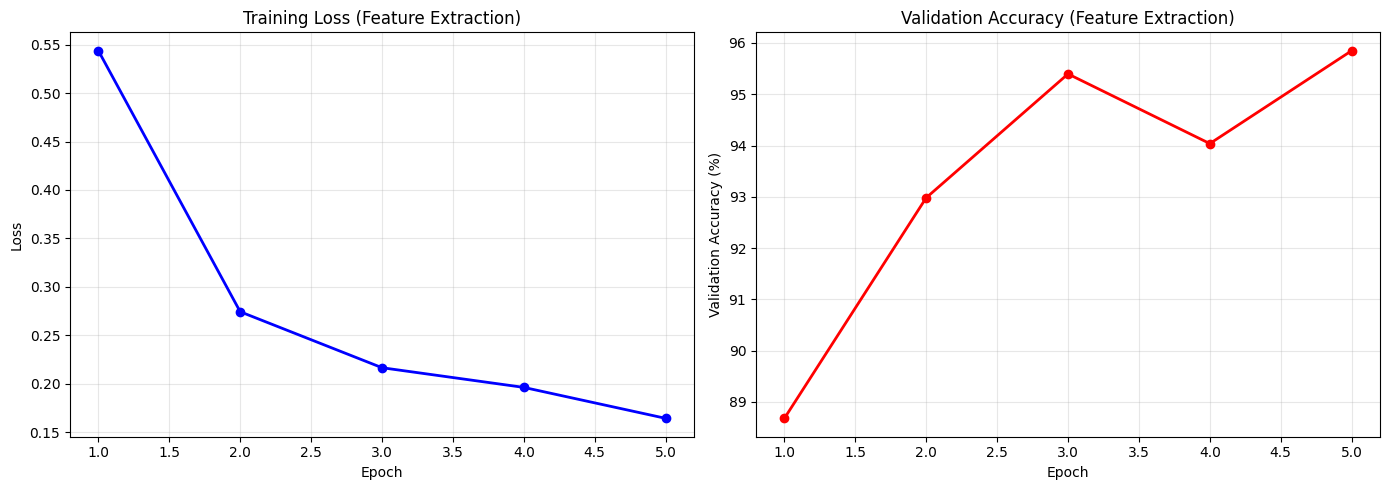

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(range(1, epochs+1), train_losses, 'bo-', linewidth=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss (Feature Extraction)')
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, epochs+1), val_accs, 'ro-', linewidth=2)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Validation Accuracy (%)')
ax2.set_title('Validation Accuracy (Feature Extraction)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task_a_feature_extraction.png', dpi=150, bbox_inches='tight')
plt.show()